# PMA Early Warnings - Recomendacion Agroclimática Estacional

**Proyecto:** Plataforma de Monitoreo Agroclimático (PMA)  
**Fuentes:** IDEAM (pronóstico estacional) + CHIRPS/AgERA5 (histórico)  
**Departamentos:** Caquetá - Amazonas - Putumayo

Produce para el mes objetivo:
1. Mapa de cambio porcentual de precipitación respecto a la climatología 1982-2025.
2. Mapa de categorías SPEI (Muy seco / Normal / Muy húmedo) mediante años análogos.
3. GeoTIFFs de ambas capas, listos para consumo externo.

In [2]:
# Instalacion de dependencias (solo en Google Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q rioxarray rasterio geopandas netCDF4 xarray requests matplotlib numpy
    print('Dependencias instaladas.')
else:
    print('Entorno local detectado.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.1 MB/s eta 0:00:00
Dependencias instaladas.


## 1. Parametros del flujo de trabajo

**Modifica aqui** el mes y anio objetivo, y los umbrales de QC.
El resto del notebook se ejecuta automaticamente a partir de estos valores.

In [3]:
# ============================================================
# PARAMETROS - MODIFICA AQUI
# ============================================================

# Periodo objetivo
MONTH = 4          # mes objetivo  (1-12)
YEAR  = 2026       # anio objetivo

# URL base pronostico IDEAM
# Plantilla: ENSAMBLE_PREC_MENSUAL_{MM}_{YYYY}.nc
IDEAM_BASE_URL = "https://bart.ideam.gov.co/wrfideam/new_modelo/CPT/netcdf/PREC"

# Archivo historico de precipitacion y SPEI
# En Colab se descarga desde GitHub; en local apunta a tu copia.
HIST_GITHUB_URL = (
    "https://raw.githubusercontent.com/dagudelo30/PMA-early_warnings/main/"
    "data/precip_spei_mensual.nc"
)
HIST_LOCAL_PATH = "../data/precip_spei_mensual.nc"

# Departamentos a procesar
DEPARTMENTS = ["Caquet\u00e1", "Amazonas", "Putumayo"]
DEPT_NE_NAMES = {
    "Caquet\u00e1":  "Caquet\u00e1",
    "Amazonas": "Amazonas",
    "Putumayo": "Putumayo",
}

# Control de calidad (QC)
QC_UPPER_FACTOR = 2.0   # si pred > factor * clim -> se trunca
QC_CAP_FACTOR   = 1.1   # cap: pred truncada a cap * clim

# Parametro K (top-K analogos para moda de SPEI)
K = 3                   # numero de anios analogos

# Directorio de salida
OUTPUT_DIR = "../outputs"

# ============================================================
# No modificar debajo de esta linea
# ============================================================
import os
MONTH_STR = f"{MONTH:02d}"
PERIOD_TAG = f"{MONTH_STR}_{YEAR}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Periodo objetivo: {MONTH_STR}/{YEAR}")
print(f"Directorio de salida: {os.path.abspath(OUTPUT_DIR)}")

Periodo objetivo: 04/2026
Directorio de salida: /outputs


## 2. Importar librerias

In [4]:
import sys, os, warnings
import requests
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from netCDF4 import Dataset
from xarray.backends import NetCDF4DataStore
from rasterio.enums import Resampling

warnings.filterwarnings('ignore')
print('Librerias importadas correctamente.')

Librerias importadas correctamente.


## 3. Cargar pronostico IDEAM

Se descarga en memoria el ensamble mensual de precipitacion del IDEAM para el periodo objetivo.

In [5]:
ideam_url = f"{IDEAM_BASE_URL}/ENSAMBLE_PREC_MENSUAL_{MONTH_STR}_{YEAR}.nc"
print(f"Descargando pronostico IDEAM: {ideam_url}")

r = requests.get(ideam_url, timeout=120)
r.raise_for_status()

nc  = Dataset("inmemory.nc", memory=r.content)
ds  = xr.open_dataset(NetCDF4DataStore(nc)).rename({"latitude": "y", "longitude": "x"})
ds  = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
ds  = ds.rio.write_crs("EPSG:4326", inplace=False)

print(f"Pronostico cargado. Variables: {list(ds.data_vars)}")
print(f"Extension: x=[{float(ds.x.min()):.2f}, {float(ds.x.max()):.2f}]  y=[{float(ds.y.min()):.2f}, {float(ds.y.max()):.2f}]")
ds

Descargando pronostico IDEAM: https://bart.ideam.gov.co/wrfideam/new_modelo/CPT/netcdf/PREC/ENSAMBLE_PREC_MENSUAL_04_2026.nc
Pronostico cargado. Variables: ['Prediccion(mm)', 'Climatologia(mm)', 'Anomalia(mm)', 'Cambio(%)', 'Prob_val_det(%)', 'Por debajo(%)', 'Normal(%)', 'Por encima(%)', 'Cond_mas_prob(%)', 'Prob_extremos(%)', 'SPI(mm)']
Extension: x=[-85.00, -65.05]  y=[-4.97, 14.97]


<xarray.Dataset> Size: 14MB
Dimensions:           (y: 400, x: 400)
Coordinates:
  * y                 (y) float64 3kB -4.975 -4.925 -4.875 ... 14.88 14.93 14.97
  * x                 (x) float64 3kB -85.0 -84.95 -84.9 ... -65.15 -65.1 -65.05
    spatial_ref       int64 8B 0
Data variables:
    Prediccion(mm)    (y, x) float64 1MB ...
    Climatologia(mm)  (y, x) float64 1MB ...
    Anomalia(mm)      (y, x) float64 1MB ...
    Cambio(%)         (y, x) float64 1MB ...
    Prob_val_det(%)   (y, x) float64 1MB ...
    Por debajo(%)     (y, x) float64 1MB ...
    Normal(%)         (y, x) float64 1MB ...
    Por encima(%)     (y, x) float64 1MB ...
    Cond_mas_prob(%)  (y, x) float64 1MB ...
    Prob_extremos(%)  (y, x) float64 1MB ...
    SPI(mm)           (y, x) float64 1MB ...

## 4. Cargar datos historicos (CHIRPS / AgERA5)

In [6]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB or not os.path.exists(HIST_LOCAL_PATH):
    print("Descargando historico desde GitHub...")
    r2 = requests.get(HIST_GITHUB_URL, timeout=300)
    r2.raise_for_status()
    nc2 = Dataset("hist_inmemory.nc", memory=r2.content)
    hist = xr.open_dataset(NetCDF4DataStore(nc2)).transpose("time", "y", "x")
else:
    print(f"Cargando historico local: {HIST_LOCAL_PATH}")
    hist = xr.open_dataset(HIST_LOCAL_PATH).transpose("time", "y", "x")

ds_filter = hist.sel(time=hist["time"].dt.month == MONTH)
print(f"Historico cargado. Variables: {list(ds_filter.data_vars)}")
print(f"Anios disponibles: {len(ds_filter.time)}")
ds_filter

Descargando historico desde GitHub...
Historico cargado. Variables: ['precip', 'spei', 'terciles']
Anios disponibles: 45


<xarray.Dataset> Size: 16MB
Dimensions:      (time: 45, y: 165, x: 180)
Coordinates:
  * time         (time) datetime64[ns] 360B 1981-04-01 1982-04-01 ... 2025-04-01
  * y            (y) float64 1kB 3.036 2.991 2.946 2.901 ... -4.265 -4.31 -4.355
  * x            (x) float64 1kB -77.29 -77.24 -77.2 ... -69.31 -69.27 -69.22
    spatial_ref  int32 4B ...
Data variables:
    precip       (time, y, x) float32 5MB ...
    spei         (time, y, x) float32 5MB ...
    terciles     (time, y, x) float32 5MB ...
Attributes: (12/15)
    DataType:                Generic
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COUNT:        29356.0
    STATISTICS_COVARIANCES:  7330.124644997384
    STATISTICS_MAXIMUM:      518.71392822266
    ...                      ...
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       85.616147104372
    scale_factor:            1.0
    add_offset:              0.0
    description:             Precipitación mensual concatenada desde GeoTIFFs

## 5. Alinear grillas (reproyectar historico a grilla IDEAM)

In [7]:
lat_min = float(ds_filter["y"].min())
lat_max = float(ds_filter["y"].max())
lon_min = float(ds_filter["x"].min())
lon_max = float(ds_filter["x"].max())

lat = ds["y"]
if lat[0] < lat[-1]:
    ds_clip = ds.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max))
else:
    ds_clip = ds.sel(y=slice(lat_max, lat_min), x=slice(lon_min, lon_max))

precip = ds_filter["precip"].rio.reproject_match(ds_clip, resampling=Resampling.bilinear)
spei   = ds_filter["spei"].rio.reproject_match(ds_clip, resampling=Resampling.nearest).round()

print(f"Grillas alineadas. Pronostico: {dict(ds_clip.sizes)}  Historico: {dict(precip.sizes)}")

Grillas alineadas. Pronostico: {'y': 148, 'x': 161}  Historico: {'time': 45, 'y': 148, 'x': 161}


## 6. Control de calidad (QC) al pronostico IDEAM

Dos reglas por pixel:
- Valores **negativos** -> reemplazados por 0 mm.
- Valores **> QC_UPPER_FACTOR x climatologia** -> truncados a QC_CAP_FACTOR x climatologia.

QC completado: 0 / 23828 pixeles modificados (0.00%)


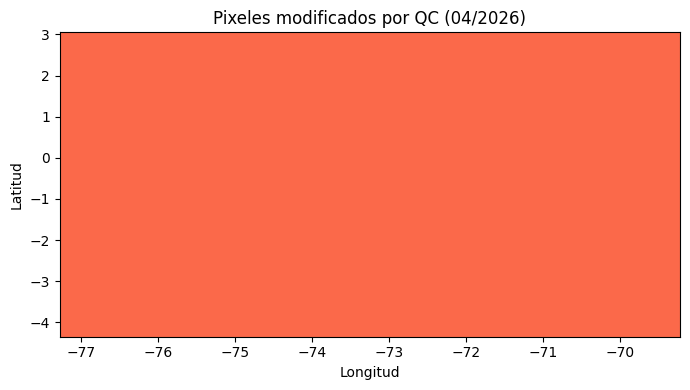

In [8]:
clim = precip.mean("time", skipna=True)
pred = ds_clip["Prediccion(mm)"].clip(min=0)
pred_qc = xr.where(pred > QC_UPPER_FACTOR * clim, QC_CAP_FACTOR * clim, pred)
ds_clip["Prediccion_QC(mm)"] = pred_qc

changed   = (pred_qc != pred) & pred.notnull()
n_changed = int(changed.sum())
n_total   = int(pred.notnull().sum())
print(f"QC completado: {n_changed} / {n_total} pixeles modificados ({100*n_changed/n_total:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
changed.astype('int8').plot(ax=ax, cmap='Reds', add_colorbar=False)
ax.set_title(f'Pixeles modificados por QC ({MONTH_STR}/{YEAR})')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/qc_pixels_{PERIOD_TAG}.png", dpi=150)
plt.show()

## 7. Cambio porcentual de precipitacion

Delta(%) = 100 * (Pf - Pclim) / Pclim

In [9]:
eps = 1e-6
cambio_pct = xr.where(clim > eps, (pred_qc - clim) / clim * 100, 0)
chg_hist   = xr.where(clim > eps, (precip - clim)  / clim * 100, 0)
print(f"Cambio porcentual: [{float(cambio_pct.min()):.1f}%, {float(cambio_pct.max()):.1f}%]")

Cambio porcentual: [-50.2%, 70.1%]


## 8. Anios analogos y moda SPEI (Top-K)

Para cada pixel:
1. Distancia absoluta entre Delta_hist(t) y Delta_f.
2. Se seleccionan los K tiempos historicos mas cercanos.
3. La recomendacion es la moda del SPEI en esos K analogos.

In [10]:
print(f"Calculando Top-{K} analogos por pixel...")

diff  = xr.apply_ufunc(np.abs, chg_hist - cambio_pct).transpose("time", "y", "x")
spei2 = spei.transpose("time", "y", "x")

d        = diff.values
T, Y, X  = d.shape
N        = Y * X
d2       = d.reshape(T, N)

idx  = np.argpartition(d2, K-1, axis=0)[:K, :]
dK   = np.take_along_axis(d2, idx, axis=0)
ordK = np.argsort(dK, axis=0)
idxK = np.take_along_axis(idx, ordK, axis=0)

spei_np   = spei2.values.reshape(T, N)
spei_topK = spei_np[idxK, np.arange(N)]

mode   = np.full(N, np.nan, dtype=np.float32)
p_mode = np.full(N, np.nan, dtype=np.float32)

for j in range(N):
    a = spei_topK[:, j]
    a = a[np.isfinite(a)]
    if a.size == 0:
        continue
    a = a.astype(np.int32)
    vals, cnts = np.unique(a, return_counts=True)
    m        = vals[np.argmax(cnts)]
    mode[j]  = m
    p_mode[j] = (a == m).mean()

spei_mode = xr.DataArray(
    mode.reshape(Y, X).astype("int16"),
    dims=("y", "x"),
    coords={"y": diff["y"], "x": diff["x"]},
    name="spei_moda"
)
spei_mode = spei_mode.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
spei_mode = spei_mode.rio.write_crs("EPSG:4326", inplace=False)

print(f"Analogos calculados (K={K}).")
cats, cnt = np.unique(mode[np.isfinite(mode)].astype(int), return_counts=True)
label_map = {1: 'Muy seco', 2: 'Normal', 3: 'Muy humedo'}
for c, n in zip(cats, cnt):
    print(f"  Cat {c} ({label_map.get(c,'?')}): {n} pixeles ({100*n/N:.1f}%)")

Calculando Top-3 analogos por pixel...
Analogos calculados (K=3).
  Cat 1 (Muy seco): 3126 pixeles (13.1%)
  Cat 2 (Normal): 19336 pixeles (81.1%)
  Cat 3 (Muy humedo): 1058 pixeles (4.4%)


## 9. Cargar limites departamentales (Natural Earth)

In [11]:
print("Descargando limites administrativos Colombia (Natural Earth 10m)...")
url_adm1 = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
adm1     = gpd.read_file(url_adm1)
col_adm1 = adm1[adm1["admin"].str.lower() == "colombia"].copy()

depts = {}
for dept in DEPARTMENTS:
    ne_name = DEPT_NE_NAMES[dept]
    gdf     = col_adm1[col_adm1["name"] == ne_name]
    if gdf.empty:
        gdf = col_adm1[col_adm1["name"].str.contains(ne_name, case=False, na=False)]
    depts[dept] = gdf
    print(f"  {dept}: {len(gdf)} poligono(s)")

print("Limites cargados.")

Descargando limites administrativos Colombia (Natural Earth 10m)...
  Caquetá: 1 poligono(s)
  Amazonas: 1 poligono(s)
  Putumayo: 1 poligono(s)
Limites cargados.


## 10. Funciones de visualizacion

In [12]:
import math
from pyproj import Geod
from rasterio.features import geometry_mask
from shapely.geometry import mapping

def add_north_arrow(ax, lon, lat, size_deg=0.3):
    """Triangulo bicolor (negro/blanco) igual al notebook original."""
    arrow_len = size_deg
    half = size_deg * 0.35
    tri_n = plt.Polygon(
        [[lon, lat], [lon - half, lat - arrow_len], [lon + half, lat - arrow_len]],
        closed=True, facecolor="0.15", edgecolor="0.15", linewidth=0.6, zorder=25
    )
    tri_e = plt.Polygon(
        [[lon, lat], [lon + half, lat - arrow_len], [lon, lat - arrow_len * 0.5]],
        closed=True, facecolor="white", edgecolor="0.15", linewidth=0.6, zorder=26
    )
    ax.add_patch(tri_n)
    ax.add_patch(tri_e)
    ax.text(lon, lat + size_deg * 0.25, "N",
            ha="center", va="bottom", fontsize=9,
            fontweight="bold", color="0.15", zorder=27)


def add_geodesic_scalebar(ax, lon_start, lat_bar, length_km=200,
                          height_deg=0.08, linewidth=0.8):
    """Barra de escala geodesica de 4 segmentos alternos (negro/blanco)."""
    geod = Geod(ellps="WGS84")
    length_m = length_km * 1000
    ndiv = 4
    seg_m = length_m / ndiv
    h = height_deg
    lon_curr = lon_start
    for i in range(ndiv):
        lon_next, _, _ = geod.fwd(lon_curr, lat_bar, 90, seg_m)
        rect = mpatches.Rectangle(
            (lon_curr, lat_bar), (lon_next - lon_curr), h,
            facecolor=("0.15" if i % 2 == 0 else "1.0"),
            edgecolor="0.15", linewidth=linewidth, zorder=20, transform=ax.transData
        )
        ax.add_patch(rect)
        lon_curr = lon_next
    lon_end, _, _ = geod.fwd(lon_start, lat_bar, 90, length_m)
    ax.add_patch(mpatches.Rectangle(
        (lon_start, lat_bar), (lon_end - lon_start), h,
        fill=False, edgecolor="0.15", linewidth=linewidth, zorder=21, transform=ax.transData
    ))
    lon_mid, _, _ = geod.fwd(lon_start, lat_bar, 90, length_m / 2)
    ax.text(lon_start, lat_bar + h * 1.5, "0",
            ha="center", va="bottom", fontsize=7.5, color="0.15", zorder=22)
    ax.text(lon_mid,   lat_bar + h * 1.5, f"{length_km//2:.0f}",
            ha="center", va="bottom", fontsize=7.5, color="0.15", zorder=22)
    ax.text(lon_end,   lat_bar + h * 1.5, f"{length_km:.0f} km",
            ha="center", va="bottom", fontsize=7.5, color="0.15", zorder=22)


def clip_raster_exact(da, gdf):
    """
    Recorte en 2 pasos:
      1) clip_box  -> reduce el array al bounding box
      2) geometry_mask -> NaN exacto fuera del shape (sin pixeles extra en el borde)
    Devuelve float32 para soportar NaN.
    """
    geom = gdf.unary_union
    minx, miny, maxx, maxy = gpd.GeoSeries([geom], crs="EPSG:4326").total_bounds
    da_bb = da.astype("float32").rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
    mask = geometry_mask(
        [mapping(geom)],
        out_shape=(da_bb.sizes["y"], da_bb.sizes["x"]),
        transform=da_bb.rio.transform(),
        invert=True,
        all_touched=False
    )
    return da_bb.where(mask)


print("Funciones de visualizacion definidas.")

Funciones de visualizacion definidas.


## 11. Generar mapas y GeoTIFFs por departamento


Procesando Caquetá...
  GeoTIFFs guardados.


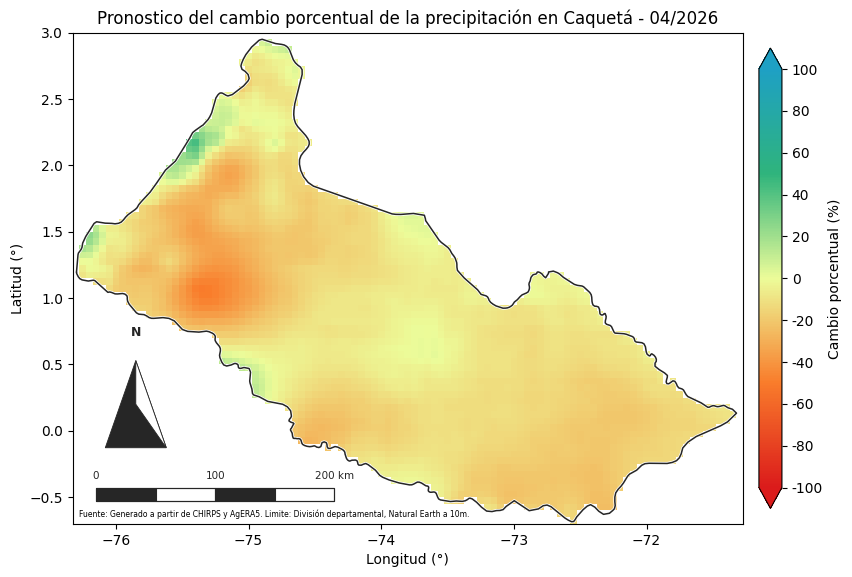

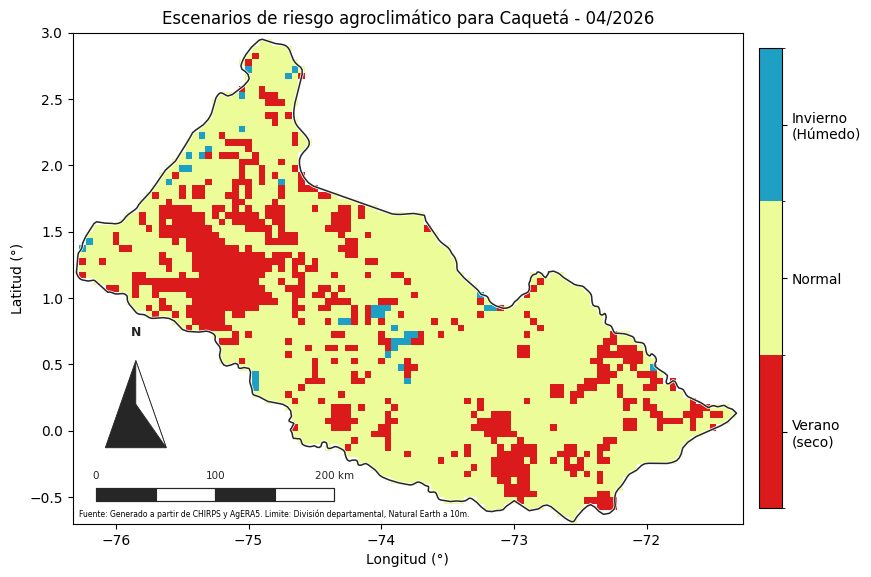

  Mapas: ../outputs/mapa_cambio_pct_04_2026_caqueta.png | ../outputs/mapa_spei_04_2026_caqueta.png

Procesando Amazonas...
  GeoTIFFs guardados.


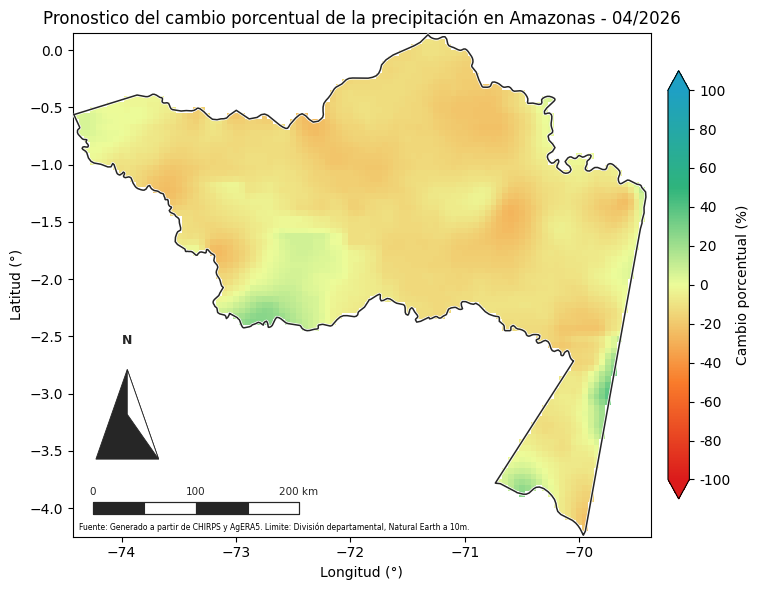

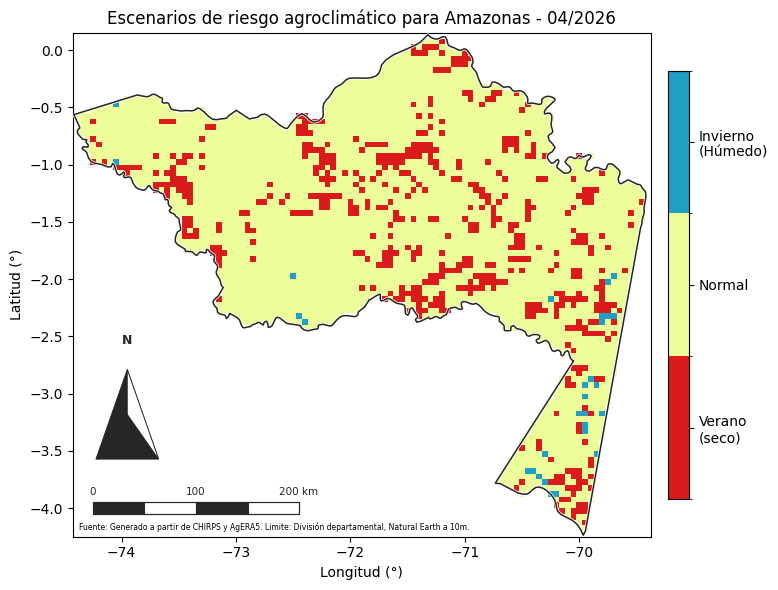

  Mapas: ../outputs/mapa_cambio_pct_04_2026_amazonas.png | ../outputs/mapa_spei_04_2026_amazonas.png

Procesando Putumayo...
  GeoTIFFs guardados.


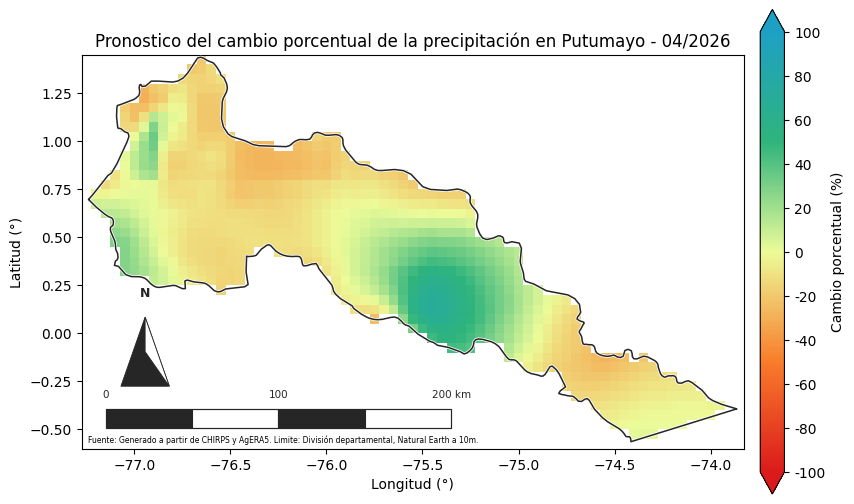

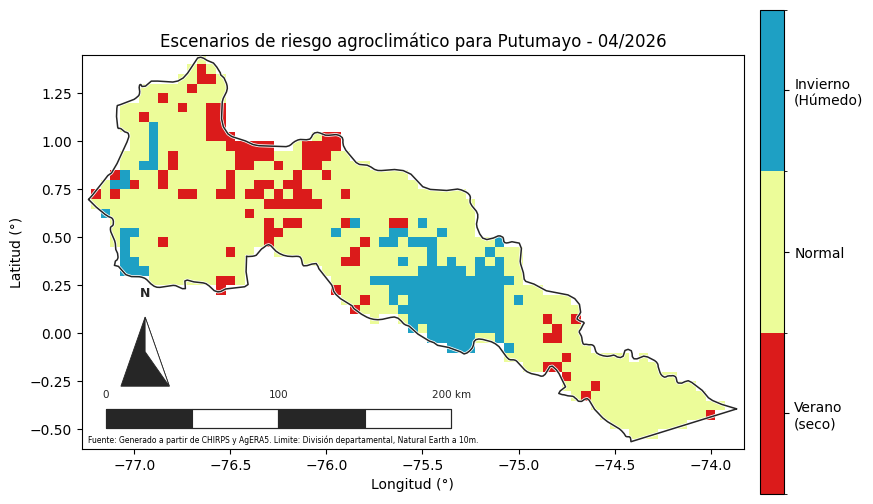

  Mapas: ../outputs/mapa_cambio_pct_04_2026_putumayo.png | ../outputs/mapa_spei_04_2026_putumayo.png

Todos los departamentos procesados.


In [23]:
# Colormap cambio porcentual
cmap_div = LinearSegmentedColormap.from_list(
    "cambio_pct",
    [(0.00, "#db1b1b"), (0.25, "#f97c2b"),
     (0.50, "#ecfc99"), (0.75, "#2fb47c"), (1.00, "#1ea0c4")],
    N=256
)

# SPEI: colores exactos del notebook original
# 1=Verano (rojo #db1b1b), 2=Normal (crema #ecfc99), 3=Invierno (azul #1ea0c4)
SPEI_CATS   = np.array([1, 2, 3])
SPEI_BOUNDS = np.array([0.5, 1.5, 2.5, 3.5])
SPEI_LABELS = {1: "Verano\n(seco)", 2: "Normal", 3: "Invierno\n(H\u00famedo)"}
cmap_spei = ListedColormap(["#db1b1b", "#ecfc99", "#1ea0c4"])
norm_spei = BoundaryNorm(SPEI_BOUNDS, cmap_spei.N)

VMIN, VMAX = -100, 100

for dept in DEPARTMENTS:
    gdf = depts[dept]
    if gdf.empty:
        print(f"Sin geometria para {dept}, se omite.")
        continue

    print(f"\nProcesando {dept}...")
    gdf = gdf.set_crs("EPSG:4326", allow_override=True).copy()
    gdf["geometry"] = gdf.geometry.buffer(0)
    slug = dept.lower().replace('\u00e1','a').replace('\u00e9','e').replace('\u00fa','u').replace('\u00f3','o')
    geom_orig = gdf.unary_union

    # ---- Recorte exacto bbox + geometry_mask ----
    def clip_exact(da_in, geom):
        minx, miny, maxx, maxy = gpd.GeoSeries([geom], crs="EPSG:4326").total_bounds
        da_bb = da_in.astype("float32").rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
        mask = geometry_mask(
            [mapping(geom)],
            out_shape=(da_bb.sizes["y"], da_bb.sizes["x"]),
            transform=da_bb.rio.transform(),
            invert=True,
            all_touched=False
        )
        return da_bb.where(mask)

    da_chg_base = cambio_pct.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
    da_chg_base = da_chg_base.rio.write_crs("EPSG:4326", inplace=False)
    da_chg_clip = clip_exact(da_chg_base, geom_orig)

    da_spei_base = spei_mode.astype("float32").rio.write_crs("EPSG:4326", inplace=False)
    da_spei_clip = clip_exact(da_spei_base, geom_orig)

    # ---- GeoTIFFs ----
    tif_chg  = f"{OUTPUT_DIR}/cambio_pct_{PERIOD_TAG}_{slug}.tif"
    tif_spei = f"{OUTPUT_DIR}/spei_moda_{PERIOD_TAG}_{slug}.tif"

    da_tmp = da_chg_clip
    if da_tmp.y.values[0] < da_tmp.y.values[-1]:
        da_tmp = da_tmp.isel(y=slice(None, None, -1)).rio.write_transform(inplace=True)
    da_tmp.rio.to_raster(tif_chg, driver="GTiff", dtype="float32", compress="LZW", nodata=float("nan"))

    da_sp = da_spei_clip
    if da_sp.y.values[0] < da_sp.y.values[-1]:
        da_sp = da_sp.isel(y=slice(None, None, -1)).rio.write_transform(inplace=True)
    da_sp.rio.to_raster(tif_spei, driver="GTiff", dtype="float32", compress="LZW", nodata=float("nan"))
    print(f"  GeoTIFFs guardados.")

    # ---- Posiciones de norte y escala (relativas al extent del mapa) ----
    x0_d = float(da_chg_clip.x.min())
    x1_d = float(da_chg_clip.x.max())
    y0_d = float(da_chg_clip.y.min())
    y1_d = float(da_chg_clip.y.max())
    dx = x1_d - x0_d
    dy = y1_d - y0_d

    LON_SCALE = x0_d + 0.03 * dx
    LAT_SCALE = y0_d + 0.04 * dy
    LON_NORTH = x0_d + 0.09 * dx
    LAT_NORTH = y0_d + 0.33 * dy
    SIZE_NORTH = 0.18 * dy

    # ============================================================
    # Mapa cambio porcentual
    # ============================================================
    # TwoSlopeNorm: ancla el cero (crema) siempre en el centro visual
    # independientemente del rango de datos del mes.
    # extend='both' muestra flechas si hay valores fuera de [-100, +100].
    from matplotlib.colors import TwoSlopeNorm
    norm_div = TwoSlopeNorm(vmin=VMIN, vcenter=0, vmax=VMAX)
    ticks_cb = list(range(VMIN, VMAX + 1, 20))  # -100,-80,...,0,...,80,100

    fig, ax = plt.subplots(figsize=(9, 6))
    im = da_chg_clip.plot(
        ax=ax, cmap=cmap_div, norm=norm_div, add_colorbar=True,
        cbar_kwargs=dict(
            shrink=0.85, pad=0.02,
            extend="both",
            ticks=ticks_cb,
            label="Cambio porcentual (%)"
        )
    )
    im.colorbar.set_ticks(ticks_cb)
    im.colorbar.set_ticklabels([str(t) for t in ticks_cb])

    gdf.boundary.plot(ax=ax, linewidth=2.2, color="white", zorder=5)
    gdf.boundary.plot(ax=ax, linewidth=1.1, color="0.15", zorder=6,
                      capstyle="round", joinstyle="round")
    add_geodesic_scalebar(ax, lon_start=LON_SCALE, lat_bar=LAT_SCALE,
                          length_km=200, height_deg=0.10)
    add_north_arrow(ax, lon=LON_NORTH, lat=LAT_NORTH, size_deg=SIZE_NORTH)
    ax.set_title(f"Pronostico del cambio porcentual de la precipitación en {dept} - {MONTH_STR}/{YEAR}")
    ax.set_xlabel("Longitud (\u00b0)"); ax.set_ylabel("Latitud (\u00b0)")
    ax.text(0.01, 0.01,  "Fuente: Generado a partir de CHIRPS y AgERA5. Limite: División departamental, Natural Earth a 10m.",
            transform=ax.transAxes, fontsize=5.5, va='bottom')
    plt.tight_layout()
    png_chg = f"{OUTPUT_DIR}/mapa_cambio_pct_{PERIOD_TAG}_{slug}.png"
    plt.savefig(png_chg, dpi=400, bbox_inches='tight')
    plt.show()

    # ============================================================
    # Mapa SPEI
    # ============================================================
    fig2, ax2 = plt.subplots(figsize=(9, 6))
    im2 = da_spei_clip.plot(
        ax=ax2, cmap=cmap_spei, norm=norm_spei, add_colorbar=True,
        cbar_kwargs=dict(
            ticks=SPEI_CATS,
            shrink=0.85, pad=0.02,
            extend="neither",
            extendrect=True
        )
    )
    im2.colorbar.set_ticklabels([SPEI_LABELS[i] for i in SPEI_CATS])
    im2.colorbar.set_label("")

    gdf.boundary.plot(ax=ax2, linewidth=2.2, color="white", zorder=5)
    gdf.boundary.plot(ax=ax2, linewidth=1.1, color="0.15", zorder=6,
                      capstyle="round", joinstyle="round")
    add_geodesic_scalebar(ax2, lon_start=LON_SCALE, lat_bar=LAT_SCALE,
                          length_km=200, height_deg=0.10)
    add_north_arrow(ax2, lon=LON_NORTH, lat=LAT_NORTH, size_deg=SIZE_NORTH)
    ax2.set_title(f"Escenarios de riesgo agroclimático para {dept} - {MONTH_STR}/{YEAR}")
    ax2.set_xlabel("Longitud (\u00b0)"); ax2.set_ylabel("Latitud (\u00b0)")
    ax2.text(0.01, 0.01, "Fuente: Generado a partir de CHIRPS y AgERA5. Limite: División departamental, Natural Earth a 10m.",
             transform=ax2.transAxes, fontsize=5.5, va='bottom')
    plt.tight_layout()
    png_spei = f"{OUTPUT_DIR}/mapa_spei_{PERIOD_TAG}_{slug}.png"
    plt.savefig(png_spei, dpi=400, bbox_inches='tight')
    plt.show()
    print(f"  Mapas: {png_chg} | {png_spei}")

print("\nTodos los departamentos procesados.")

## 12. Resumen de archivos generados

In [24]:
import glob
files = sorted(glob.glob(f"{OUTPUT_DIR}/*{PERIOD_TAG}*"))
print(f"Archivos generados para {PERIOD_TAG}:")
for f in files:
    size = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):55s}  {size:8.1f} KB")
print(f"\nTotal: {len(files)} archivo(s)")

Archivos generados para 04_2026:
  cambio_pct_04_2026_amazonas.tif                              17.7 KB
  cambio_pct_04_2026_caqueta.tif                               14.6 KB
  cambio_pct_04_2026_putumayo.tif                               4.9 KB
  mapa_cambio_pct_04_2026_amazonas.png                        423.7 KB
  mapa_cambio_pct_04_2026_caqueta.png                         405.1 KB
  mapa_cambio_pct_04_2026_putumayo.png                        391.3 KB
  mapa_spei_04_2026_amazonas.png                              382.5 KB
  mapa_spei_04_2026_caqueta.png                               364.8 KB
  mapa_spei_04_2026_putumayo.png                              355.6 KB
  qc_pixels_04_2026.png                                        24.1 KB
  spei_moda_04_2026_amazonas.tif                                3.0 KB
  spei_moda_04_2026_caqueta.tif                                 2.7 KB
  spei_moda_04_2026_putumayo.tif                                1.4 KB

Total: 13 archivo(s)
